In [4]:
# Importaciones base y modulos del proyecto
import sys
import numpy as np
import matplotlib.pyplot as plt

# Agregar el root del proyecto para importar src/
sys.path.append(r"c:/Users/sebas/MalariaProject/src")

# Modelos 2D
from model2D_v3 import Params2D as Params2D_2D, KMC2D as KMC2D_2D, KMC2DVisualizer

# Modelos 3D (BKL unificado)
from bkl_v4 import KMC_BKL_v4
from lattice_v4 import LatticeSOS_v4
from params_v4 import KMCParams_v4
from params_v2 import KMCParams_v2

0.0
0.460211265957598
0.8100915042739736
0.9932070476518712
1.2310180754086744
1.3560509372071627
1.481531537785739
1.612171099335505
1.7738890342172544
1.930061710462336
1.9967535525178777
2.123558421294161
2.1740277758891957
2.254468135545758
2.318205332307518
2.3844145798839853
2.4497353952560013
2.518361203757235
2.5835041614124887
2.6426812233700536
2.716179522139646
2.7738092790634097
2.842811988416809
2.8959266717058934
2.9354647450940394
2.975783255324959
3.038405887557642
3.079676783277942
3.1249951488223235
3.1807699718024596
3.2332941601939615
3.2777639396914355
3.3216011291768757
3.361548917025014
3.412809450971018
3.4614823694485204
3.498575630529717
3.547402277615244
3.5864048238049437
3.6199845795631607
3.6503834899197294
3.6870089414807463
3.720571117573758
3.752662279525591
3.7883916678967626
3.8299297771702125
3.856411674186647
3.8895072883870156
3.9218598457523206
3.96223522311184
4.012574610814866
4.050064118549926
4.094174467737634
4.135810231326971
4.1880598650726

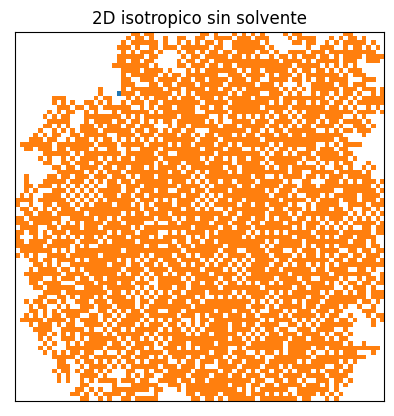

t_final=5.002, coverage_final=0.619


In [6]:
# 2D isotropico: sin anisotropia ni solvente
params = Params2D_2D()
kmc = KMC2D_2D(params, seed=1, use_anisotropy=False, use_solvent=False)
times, cover, snapshots = kmc.run_until(tmax=5.0, snapshot_every=0.5, store_snapshots=True)
if not snapshots:
    snapshots = [(kmc.t, kmc.grid.copy())]
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title="2D isotropico sin solvente", show=True)
print(f"t_final={kmc.t:.3f}, coverage_final={cover[-1] if len(cover) else 0.0:.3f}")

0.0
1.050697739192318
1.326495414629088
1.6069828391390442
1.803267281121402
1.9020112287090896
2.0280927831837494
2.1221788182864696
2.274140707187742
2.445813972350101
2.5420217042535547
2.662166223809109
2.7687986644007627
2.897126998547388
2.9855296077166895
3.090348535831718
3.206039273718705
3.2902131253165012
3.3781222040120302
3.471893365734002
3.5664782439393323
3.6984376573184847
3.808600746654407
3.883834576171679
3.9822110733532057


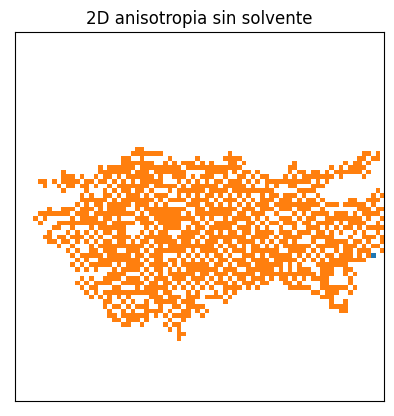

t_final=4.001, coverage_final=0.210


In [8]:
# 2D con anisotropia, sin solvente
params = Params2D_2D(
    Jad_x=0.08, Jad_y=0.02,
    Jinc_x=0.02, Jinc_y=0.01,
    Jdes_x=0.06, Jdes_y=0.03,
    Jmove_x=0.05, Jmove_y=0.02,
)
kmc = KMC2D_2D(params, seed=2, use_anisotropy=True, use_solvent=False)
times, cover, snapshots = kmc.run_until(tmax=4.0, snapshot_every=0.5, store_snapshots=True)
if not snapshots:
    snapshots = [(kmc.t, kmc.grid.copy())]
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title="2D anisotropia sin solvente", show=True)
print(f"t_final={kmc.t:.3f}, coverage_final={cover[-1] if len(cover) else 0.0:.3f}")

0.0


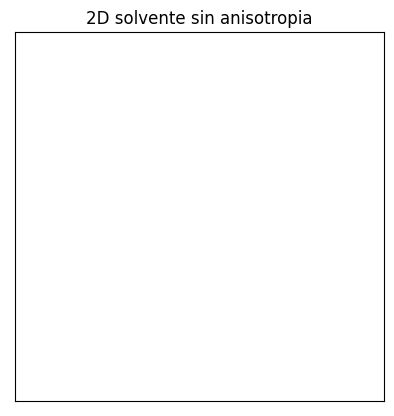

t_final=0.000, coverage_final=0.000


In [10]:
# 2D con solvente, sin anisotropia
params = Params2D_2D(
    Jad_x=0.04, Jad_y=0.04,
    Jinc_x=0.01, Jinc_y=0.01,
    Jdes_x=0.05, Jdes_y=0.05,
    Jmove_x=0.03, Jmove_y=0.03,
    solvent_ads_factor=0.7,
    solvent_des_factor=0.12,
    solvent_diff_factor=0.16,
    solvent_inc_factor=0.18,
)
kmc = KMC2D_2D(params, seed=3, use_anisotropy=False, use_solvent=True)
times, cover, snapshots = kmc.run_until(tmax=4.0, snapshot_every=0.5, store_snapshots=True)
if not snapshots:
    snapshots = [(kmc.t, kmc.grid.copy())]
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title="2D solvente sin anisotropia", show=True)
print(f"t_final={kmc.t:.3f}, coverage_final={cover[-1] if len(cover) else 0.0:.3f}")

0.0


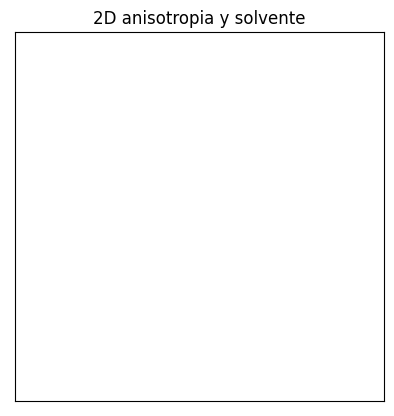

t_final=0.000, coverage_final=0.000


In [11]:
# 2D con anisotropia y solvente
params = Params2D_2D(
    Jad_x=0.07, Jad_y=0.03,
    Jinc_x=0.02, Jinc_y=0.01,
    Jdes_x=0.06, Jdes_y=0.04,
    Jmove_x=0.05, Jmove_y=0.02,
    solvent_ads_factor=0.6,
    solvent_des_factor=0.5,
    solvent_diff_factor=0.7,
    solvent_inc_factor=0.9,
)
kmc = KMC2D_2D(params, seed=4, use_anisotropy=True, use_solvent=True)
times, cover, snapshots = kmc.run_until(tmax=2.0, snapshot_every=0.5, store_snapshots=True)
if not snapshots:
    snapshots = [(kmc.t, kmc.grid.copy())]
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title="2D anisotropia y solvente", show=True)
print(f"t_final={kmc.t:.3f}, coverage_final={cover[-1] if len(cover) else 0.0:.3f}")

In [12]:
# 3D con concentracion dinamica, sin anisotropia ni solvente
lat = LatticeSOS_v4(size=16, seed=10)
lat.initialize(mode="flat")
params = KMCParams_v2(
    K0_plus=1e4,
    E_pb_over_kT=2.0,
    phi_over_kT=5.0,
    delta=0.4,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
)
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=11,
    time_scale=1.0,
    n_seeds=5,
    debug=False,
    constant_concentration=False,
    use_anisotropy=False,
    use_solvent=False,
)
snapshot_times = np.linspace(0.2, 1.5, 6).tolist()
snaps, stats = kmc.run(t_end=1.5, snapshot_times=snapshot_times, max_events=12000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
mean_height = float(np.mean(snaps[-1][1]))
print(f"mean_height={mean_height:.3f}")
print("event_counts=", stats["event_counts"])

mean_height=2.934
event_counts= {'adsorption': 3144, 'desorption': 2398, 'migration': 6458, 'incorporation': 0}


🧩 Usando estado actual: t=0.000


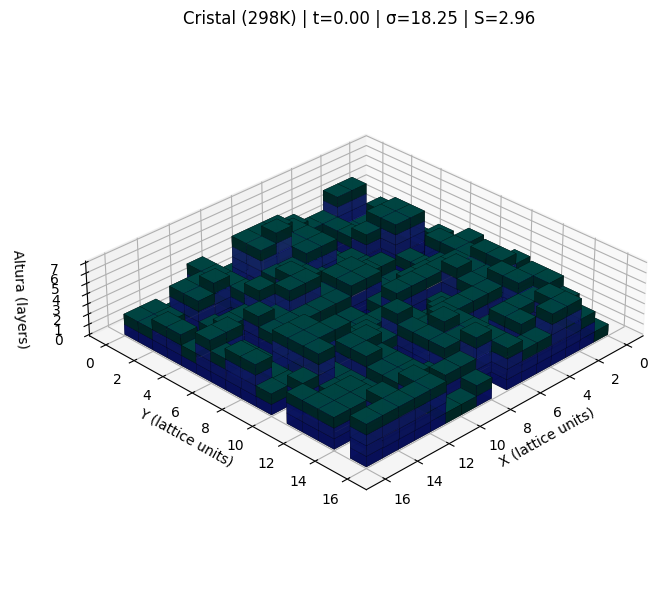

In [21]:
from plotter_v2 import Plotter_v2

plots = Plotter_v2(kmc)
plots.plot_crystal_3d()

In [22]:
# 3D con concentracion estatica, sin anisotropia ni solvente
lat = LatticeSOS_v4(size=16, seed=20)
lat.initialize(mode="flat")
params = KMCParams_v2(
    K0_plus=1e4,
    E_pb_over_kT=2.0,
    phi_over_kT=5.0,
    delta=0.4,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
)
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=21,
    time_scale=1.0,
    n_seeds=5,
    debug=False,
    constant_concentration=True,
    use_anisotropy=False,
    use_solvent=False,
)
snapshot_times = np.linspace(0.2, 1.5, 6).tolist()
snaps, stats = kmc.run(t_end=1.5, snapshot_times=snapshot_times, max_events=12000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
mean_height = float(np.mean(snaps[-1][1]))
print(f"mean_height={mean_height:.3f}")
print("event_counts=", stats["event_counts"])

mean_height=2.551
event_counts= {'adsorption': 3066, 'desorption': 2418, 'migration': 6516, 'incorporation': 0}


🧩 Usando estado actual: t=0.000


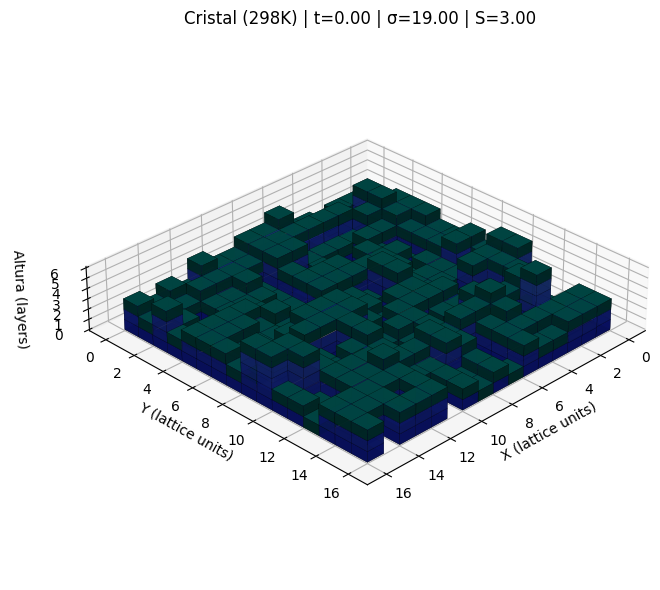

In [23]:
plots = Plotter_v2(kmc)
plots.plot_crystal_3d()

In [24]:
# 3D con concentracion estatica, con solvente y sin anisotropia
lat = LatticeSOS_v4(size=16, seed=30)
lat.initialize(mode="flat")
params = KMCParams_v4(
    K0_plus=1e4,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=2.0,
    phi_over_kT=5.0,
    delta_x=0.4,
    delta_y=0.4,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
    solvent_ads_factor=0.7,
    solvent_des_factor=0.5,
    solvent_mig_factor=0.6,
)
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=31,
    time_scale=1.0,
    n_seeds=5,
    debug=False,
    constant_concentration=True,
    use_anisotropy=False,
    use_solvent=True,
)
snapshot_times = np.linspace(0.2, 1.5, 6).tolist()
snaps, stats = kmc.run(t_end=1.5, snapshot_times=snapshot_times, max_events=12000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
mean_height = float(np.mean(snaps[-1][1]))
print(f"mean_height={mean_height:.3f}")
print("event_counts=", stats["event_counts"])

mean_height=3.531
event_counts= {'adsorption': 3057, 'desorption': 2158, 'migration': 6785, 'incorporation': 0}


🧩 Usando estado actual: t=0.000


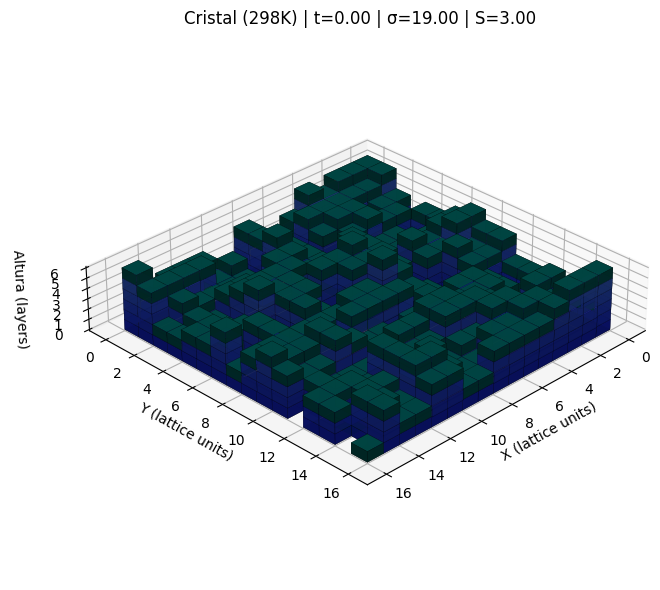

In [25]:
plots = Plotter_v2(kmc)
plots.plot_crystal_3d()

In [26]:
# 3D con concentracion estatica, con anisotropia y sin solvente
lat = LatticeSOS_v4(size=16, seed=40)
lat.initialize(mode="flat")
params = KMCParams_v4(
    K0_plus=1e4,
    E_pb_over_kT_x=2.4,
    E_pb_over_kT_y=1.6,
    phi_over_kT=5.0,
    delta_x=0.5,
    delta_y=0.3,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
)
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=41,
    time_scale=1.0,
    n_seeds=5,
    debug=False,
    constant_concentration=True,
    use_anisotropy=True,
    use_solvent=False,
)
snapshot_times = np.linspace(0.2, 1.5, 6).tolist()
snaps, stats = kmc.run(t_end=1.5, snapshot_times=snapshot_times, max_events=12000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
mean_height = float(np.mean(snaps[-1][1]))
print(f"mean_height={mean_height:.3f}")
print("event_counts=", stats["event_counts"])

mean_height=2.617
event_counts= {'adsorption': 3034, 'desorption': 2369, 'migration': 6597, 'incorporation': 0}


🧩 Usando estado actual: t=0.000


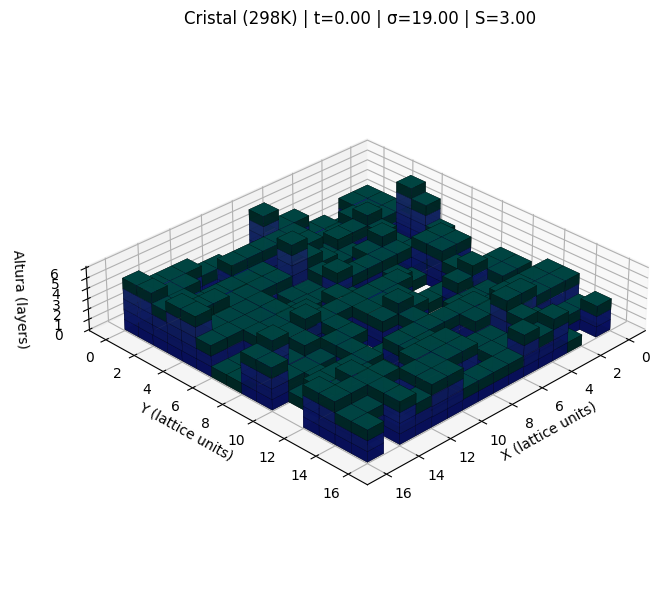

In [27]:
plots = Plotter_v2(kmc)
plots.plot_crystal_3d()

In [28]:
# 3D con concentracion estatica, con anisotropia y solvente
lat = LatticeSOS_v4(size=16, seed=50)
lat.initialize(mode="flat")
params = KMCParams_v4(
    K0_plus=1e4,
    E_pb_over_kT_x=2.4,
    E_pb_over_kT_y=1.6,
    phi_over_kT=5.0,
    delta_x=0.5,
    delta_y=0.3,
    V=1.0,
    C_eq=1e3,
    fixed_sigma=None,
    S_floor=-5.0,
    S_ceil=8.0,
    solvent_ads_factor=0.7,
    solvent_des_factor=0.5,
    solvent_mig_factor=0.6,
)
kmc = KMC_BKL_v4(
    lattice=lat,
    params=params,
    N_bulk0=20000,
    rng_seed=51,
    time_scale=1.0,
    n_seeds=5,
    debug=False,
    constant_concentration=True,
    use_anisotropy=True,
    use_solvent=True,
)
snapshot_times = np.linspace(0.2, 1.5, 6).tolist()
snaps, stats = kmc.run(t_end=1.5, snapshot_times=snapshot_times, max_events=12000)
if not snaps:
    snaps = [(kmc.t, kmc.lat.heights.copy(), 0.0)]
mean_height = float(np.mean(snaps[-1][1]))
print(f"mean_height={mean_height:.3f}")
print("event_counts=", stats["event_counts"])

mean_height=3.953
event_counts= {'adsorption': 3059, 'desorption': 2052, 'migration': 6889, 'incorporation': 0}


🧩 Usando estado actual: t=0.000


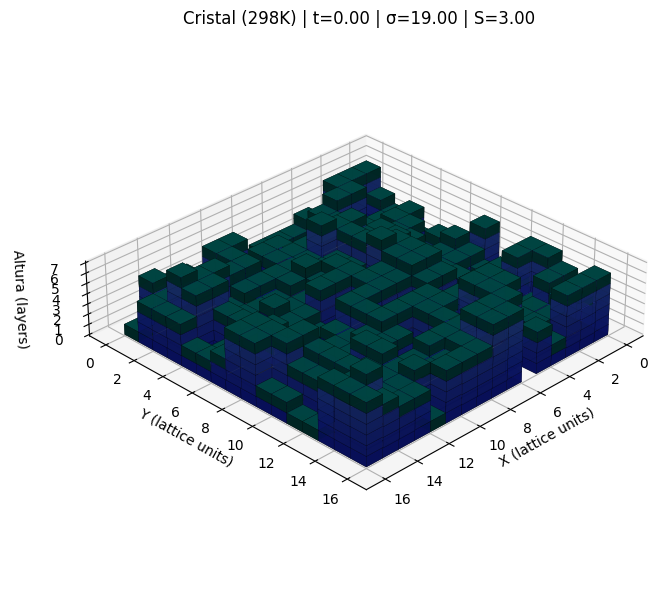

In [29]:
plots = Plotter_v2(kmc)
plots.plot_crystal_3d()